In [11]:
import os
import tensorflow as tf
import numpy as np
from tqdm import tqdm
import tensorflow_datasets as tfds

import matplotlib.pyplot as plt
%matplotlib inline  

import importlib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pprint

import keras_tuner
import pandas as pd

tfk = tf.keras
tfkl = tfk.layers

Import Kaggle training and test datasets. 

In [12]:
def datasets_from_csv(file_name:str, batch_size:int=512, validation_split:float = 0.2):
    csv_df = pd.read_csv(file_name)
    full_dataset = tf.data.Dataset.zip(
        tf.data.Dataset.from_tensor_slices(
            tf.cast(
            tf.reshape(tf.convert_to_tensor(csv_df[['pixel{}'.format(i) for i in range(784)]]), [-1, 28,28,1]), 
            tf.float32
            )
        ), 
        tf.data.Dataset.from_tensor_slices(
            tf.cast(
            tf.reshape(tf.convert_to_tensor(csv_df['label']), [-1, 1]), 
            tf.int32
            )
        )
    )

    full_dataset = full_dataset.cache().shuffle(full_dataset.cardinality())

    if validation_split == 0:
        return full_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    else:
        train_size = int((1.0 - validation_split) * full_dataset.cardinality().numpy())
        train_ds = full_dataset.take(train_size)
        val_ds = full_dataset.skip(train_size)

        train_ds = train_ds.cache().shuffle(train_ds.cardinality()).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        val_ds = val_ds.cache().shuffle(val_ds.cardinality()).batch(batch_size).prefetch(tf.data.AUTOTUNE)

        return train_ds, val_ds

In [13]:
BATCH_SIZE = 512

train_ds, val_ds = datasets_from_csv('kaggle/train.csv', BATCH_SIZE, validation_split=0.15)


Define a hypermodel

In [36]:
def build_model(hp):

    module = importlib.import_module('arnold.layers')

    model = tfk.Sequential()
    # augmentation layers
    model.add(tfkl.RandomFlip(mode="horizontal_and_vertical"))
    model.add(tfkl.RandomTranslation(height_factor=(-0.2, 0.3), width_factor=(-0.2, 0.3), fill_mode="reflect", interpolation="bilinear", fill_value=0.0, data_format="channels_last"))
    model.add(tfkl.RandomRotation(factor=(-0.2, 0.3), fill_mode="reflect", interpolation="bilinear", fill_value=0.0, value_range=(0, 255), data_format="channels_last"))
    model.add(tfkl.RandomZoom(height_factor=(0.2, 0.3), width_factor=(0.2, 0.3), fill_mode="reflect", interpolation="bilinear", fill_value=0.0, data_format="channels_last"))
    model.add(tfkl.RandomContrast(factor=(0.1, 0.2)))
    model.add(tfkl.RandomBrightness(factor=(-0.2, 0.2), value_range=(0, 255)))
     
    model.add(tfkl.Reshape(target_shape=(784, )))
    model.add(tfkl.Rescaling(scale=1./255., offset=0.))

    from arnold.layers.polynomial.orthogonal import Pollaczek
    available_layers =  [
        # "Poisson",
        # "Ricker",
        # "Morelet",
        # "Meyer",
        # "Shannon",
        # "Bump",
        # "DerivativeOfGaussian",
        # "GaussianRBF", 
        # "InverseQuadraticRBF",
        # "InverseMultiQuadricRBF",
        "Boubaker",
        "Laurent",
        "AlSalamCarlitz1st", 
        "AlSalamCarlitz2nd",
        "AskeyWilson",
        "BannaiIto",
        "Bessel",
        "Charlier",
        "Chebyshev1st", 
        "Chebyshev2nd",
        "Chebyshev3rd", 
        "Chebyshev4th",
        "Gegenbauer", 
        "Hermite",
        "Jacobi",
        "GeneralizedLaguerre",
        "Legendre",
        "AssociatedMeixnerPollaczek",
        "Pollaczek"
    ]

    # first KAN layer
    model.add(
        getattr(module, hp.Choice('layer_type_0', available_layers))(
            input_dim=784,
            output_dim=hp.Int("output_dim_0", min_value=8, max_value=64, step=16),
            degree=hp.Int("degree_0", min_value=1, max_value=8, step=1),
        )
    )

    # Tune the number of layers.
    for i in range(hp.Int("num_layers", 1, 8)):

        model.add(tfkl.LayerNormalization())

        model.add(
           getattr(module, hp.Choice('layer_type_{}'.format(i+1), available_layers))(
                input_dim=hp.get('output_dim_{}'.format(i)),
                output_dim=hp.Int("output_dim_{}".format(i+1), min_value=8, max_value=64, step=16),
                degree=hp.Int("degree_{}".format(i+1), min_value=1, max_value=8, step=1),
            )
        )

    # last KAN layer
    model.add(tfkl.LayerNormalization())
    model.add(
        getattr(module, hp.Choice('layer_type_{}'.format(hp.get('num_layers') + 1), available_layers))(
            input_dim=hp.get('output_dim_{}'.format(hp.get('num_layers') )),
            output_dim=10,
            degree=hp.Int('degree_{}'.format(hp.get('num_layers') + 1), min_value=1, max_value=8, step=1),
        )
    )
    model.add(tfkl.Softmax())


    learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    model.compile(
        optimizer=tfk.optimizers.Nadam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    return model

In [37]:
tuner = keras_tuner.Hyperband(
    hypermodel=build_model,
    objective="val_accuracy",
    max_epochs=10,
    factor=3,
    hyperband_iterations=1,
    seed=None,
    hyperparameters=None,
    tune_new_entries=True,
    allow_new_entries=True,
    max_retries_per_trial=0,
    max_consecutive_failed_trials=3,
    directory='kaggle_tuning_unit_aug',
    project_name='digit_recognizer'
)

In [38]:
tuner.search_space_summary()

Search space summary
Default search space size: 10
layer_type_0 (Choice)
{'default': 'Boubaker', 'conditions': [], 'values': ['Boubaker', 'Laurent', 'AlSalamCarlitz1st', 'AlSalamCarlitz2nd', 'AskeyWilson', 'BannaiIto', 'Bessel', 'Charlier', 'Chebyshev1st', 'Chebyshev2nd', 'Chebyshev3rd', 'Chebyshev4th', 'Gegenbauer', 'Hermite', 'Jacobi', 'GeneralizedLaguerre', 'Legendre', 'AssociatedMeixnerPollaczek', 'Pollaczek'], 'ordered': False}
output_dim_0 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
degree_0 (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 8, 'step': 1, 'sampling': 'linear'}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 8, 'step': 1, 'sampling': 'linear'}
layer_type_1 (Choice)
{'default': 'Boubaker', 'conditions': [], 'values': ['Boubaker', 'Laurent', 'AlSalamCarlitz1st', 'AlSalamCarlitz2nd', 'AskeyWilson', 'BannaiIto', 'Bessel', 'Charlier', 'Chebyshev1st', '

In [39]:
tuner.search(train_ds, epochs=10, validation_data=val_ds)

Trial 30 Complete [00h 00m 17s]
val_accuracy: 0.11444444209337234

Best val_accuracy So Far: 0.3160317540168762
Total elapsed time: 00h 05m 22s


In [40]:
tuner.get_best_models()[0].summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 28, 28, 1)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 28, 28, 1)      │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bannai_ito (BannaiIto)          │ (None, 24)             │       131,715 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 24)             │            48 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ charlier (Charlier)             │ (None, 8)              │         1,345 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 8)              │            16 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ associated_meixner_pollaczek    │ (None, 40)             │         1,283 │
│ (AssociatedMeixnerPollaczek)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 40)             │            80 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev4th (Chebyshev4th)     │ (None, 24)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 24)             │            48 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gegenbauer (Gegenbauer)         │ (None, 10)             │         1,441 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,776 (549.91 KB)

 Trainable params: 140,776 (549.91 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
best_hps=tuner.get_best_hyperparameters()[0]
best_hps
model = tuner.hypermodel.build(best_hps)
history = model.fit(train_ds, epochs=100, validation_data=val_ds)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1374 - loss: 2.2730 - val_accuracy: 0.1581 - val_loss: 2.1868
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.1666 - loss: 2.2157 - val_accuracy: 0.1717 - val_loss: 2.1971
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2273 - loss: 2.1012 - val_accuracy: 0.2214 - val_loss: 2.1970
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2689 - loss: 1.9907 - val_accuracy: 0.2337 - val_loss: 2.2160
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2889 - loss: 1.9129 - val_accuracy: 0.3168 - val_loss: 2.1000
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3125 - loss: 1.8700 - val_accuracy: 0.3163 - val_loss: 2.0665
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3235 - loss: 1.8294 - val_accuracy: 0.3233 - val_loss: 1.9763
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3388 - loss: 1.7976 - val_accuracy: 0.

In [35]:
best_hps.values

{'layer_type_0': 'Chebyshev1st',
 'output_dim_0': 40,
 'degree_0': 7,
 'num_layers': 1,
 'layer_type_1': 'Pollaczek',
 'output_dim_1': 56,
 'degree_1': 8,
 'layer_type_2': 'AssociatedMeixnerPollaczek',
 'degree_2': 7,
 'lr': 0.00011676150871319965,
 'output_dim_2': 8,
 'layer_type_3': 'Gegenbauer',
 'output_dim_3': 56,
 'degree_3': 2,
 'layer_type_4': 'AlSalamCarlitz1st',
 'output_dim_4': 40,
 'degree_4': 2,
 'layer_type_5': 'GeneralizedLaguerre',
 'output_dim_5': 56,
 'degree_5': 2,
 'layer_type_6': 'BannaiIto',
 'output_dim_6': 24,
 'degree_6': 2,
 'layer_type_7': 'Jacobi',
 'degree_7': 4,
 'output_dim_7': 56,
 'layer_type_8': 'Bessel',
 'output_dim_8': 56,
 'degree_8': 4,
 'layer_type_9': 'Chebyshev3rd',
 'degree_9': 5,
 'tuner/epochs': 10,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 0,
 'tuner/round': 0}

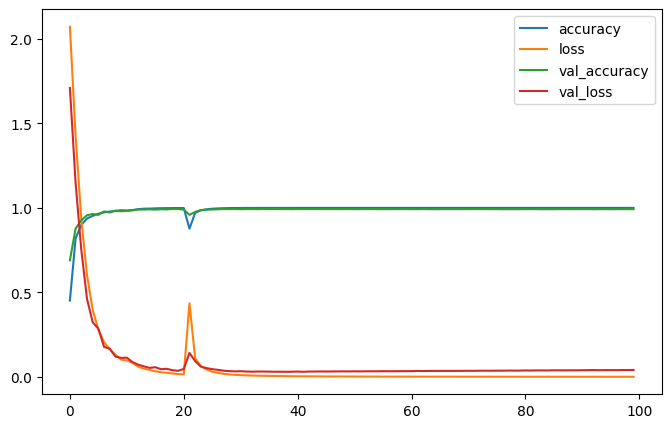

In [31]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [32]:
test_ds = tf.data.Dataset.from_tensor_slices(
    tf.cast(
        tf.reshape(
            tf.convert_to_tensor(pd.read_csv('kaggle/test.csv')),
            [-1, 28, 28, 1]
        ),
        tf.float32
    )
)
test_ds = test_ds.cache().batch(1024).prefetch(tf.data.AUTOTUNE)

In [33]:
y_pred = np.argmax(model.predict(test_ds), axis=-1)
y_pred[0:10]

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


array([2, 0, 9, 9, 3, 7, 0, 3, 0, 3])

In [23]:
it = iter(test_ds)

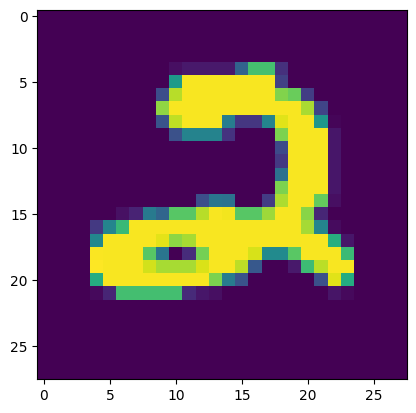

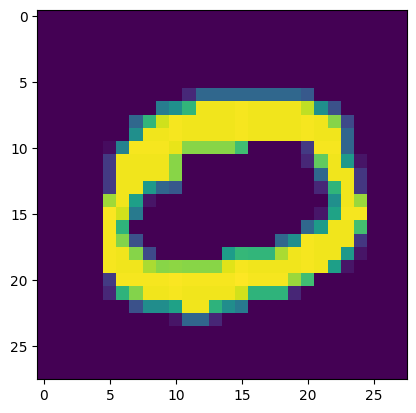

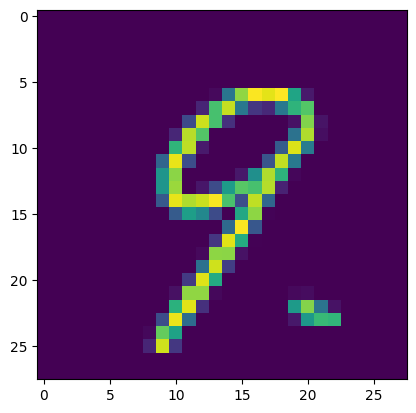

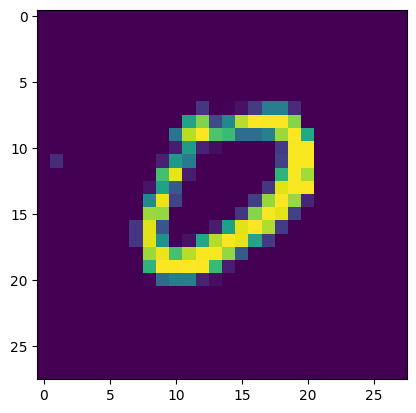

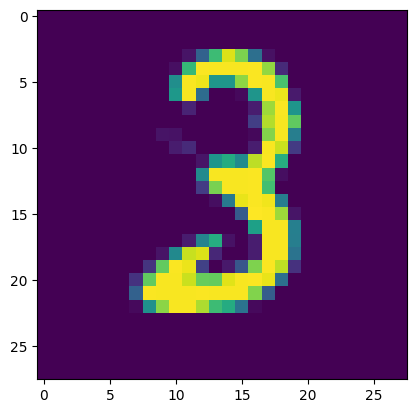

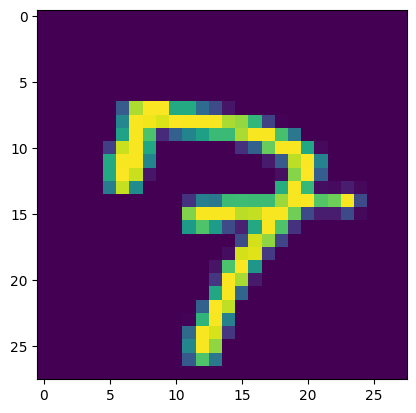

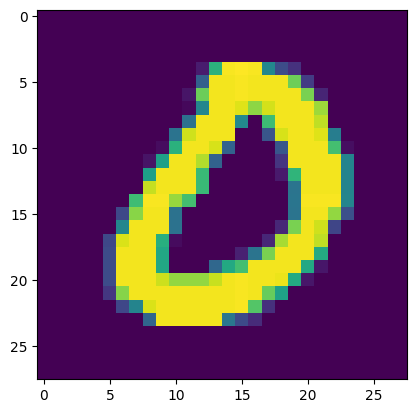

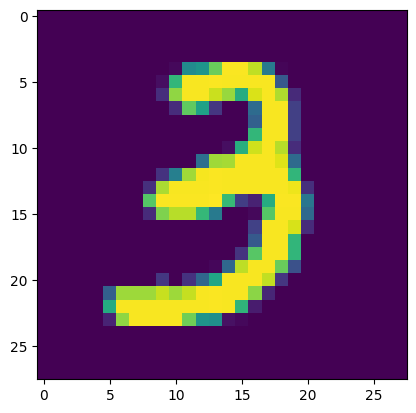

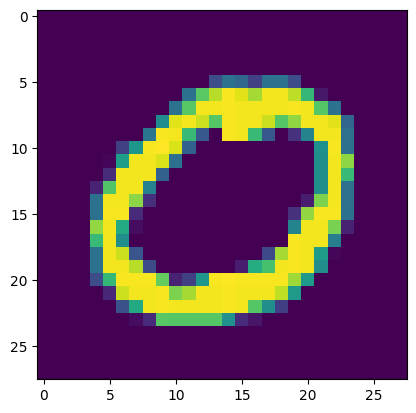

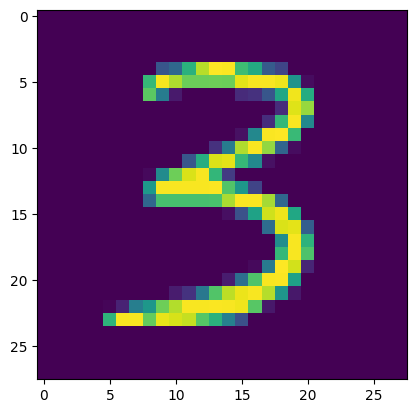

In [24]:
for img in next(it)[0:10]:
    plt.figure()
    plt.imshow(img)
    plt.show()

In [ ]:
model = arnold.Sequential([
    
])